In [2]:
from WKAN import *

CUDA is available. Using GPU.


In [3]:
# import data

dataSectionT1 = sc.read("data/LIBD/data_151673.h5ad")
dataSectionT2 = sc.read("data/LIBD/data_151674.h5ad")
dataSectionT3 = sc.read("data/LIBD/data_151675.h5ad")
dataSectionM = sc.read("data/LIBD/MergeTrains737475.h5ad")
dataSectionT4 = sc.read("data/LIBD/data_151676.h5ad")
dataSectionT5 = sc.read("data/LIBD/data_151507.h5ad")

In [4]:
# Remove useless label

mask = dataSectionT4.obs['Layer'] != 0
dataSectionT4_NoZero = dataSectionT4[mask].copy()

mask = dataSectionT5.obs['Layer'] != 0
dataSectionT5_NoZero = dataSectionT5[mask].copy()

In [5]:
## Count the number of spots on each layer
layer_count =  dataSectionM.obs["Layer"].value_counts().sort_index()
## The weight is given by the ratio of the count to the count of layer 1 (Layer 1 excluded)
layer_weight = layer_count[7]/layer_count[0:7]
layer_weights = torch.tensor(layer_weight.to_numpy())

In [6]:
# For Windows set to 0 
num_workers = 0

In [6]:
# Self-select from Self:
with open("output/LIBD/Pred_LIBD_FullG1425.obj",'rb') as file:
        LIBD_FullG = pickle.load(file)

In [9]:
def gene_filter(model_weight, top_n):
    top_n = top_n
    model_weight = model_weight
    
    values, index = model_weight.topk(top_n, dim = 1)

    empty_set = set()
    
    for i in range(index.size(0)):
        new_set = set(index[i].tolist())  # 转换为集合（如果它不是的话）
        empty_set = empty_set.union(new_set)  # 使用 union 方法合并集合

    # assert len(list(empty_set)) == num_gene

    return list(empty_set)

In [10]:
def gene_selector(model_weight, top_n):
    top_n = top_n
    model_weight = model_weight
    
    values, index = model_weight.topk(top_n, dim = 1)

    empty_set = set()
    
    for i in range(index.size(0)):
        new_set = set(index[i].tolist())  # 转换为集合（如果它不是的话）
        empty_set = empty_set.union(new_set)  # 使用 union 方法合并集合

    # assert len(list(empty_set)) == num_gene

    return list(empty_set)

In [9]:
# Select 651genes from trained KAN:
dataSectionM_651 = dataSectionM[:, gene_filter(model_weight = LIBD_FullG.fclayer1[0].spline_scaler, top_n= 8)]

In [10]:
len(gene_filter(model_weight = LIBD_FullG.fclayer1[0].spline_scaler, top_n= 4))

349

In [11]:
len(gene_filter(model_weight = LIBD_FullG.fclayer1[0].spline_scaler, top_n= 2))

166

In [12]:
dataSectionM

AnnData object with n_obs × n_vars = 10904 × 1425
    obs: 'x2', 'x3', 'Layer', 'Layer_character', 'n_counts', 'batch'
    var: 'gene_ids', 'feature_types', 'genome', 'genename'

In [14]:
import scanpy as sc
import pandas as pd

def process_and_output_layer_genes_simple(adata, studyID):
    if "Layer" not in adata.obs:
        raise ValueError("The column 'Layer' is missing in adata.obs. Please provide a valid grouping column.")
    if adata.obs["Layer"].dtype != "category":
        adata.obs["Layer"] = adata.obs["Layer"].astype("category")
    
    sc.tl.rank_genes_groups(adata, groupby="Layer", method="wilcoxon", key_added="wilcoxon")
    
    sc.pl.rank_genes_groups(adata, key="wilcoxon", show=False, save=f"_top_genes_{studyID}.png")
    
    result = pd.DataFrame(adata.uns["wilcoxon"]["names"]).iloc[:50]
    result.to_csv(f"top_DE_genes_{studyID}.csv", index=False)
    print(f"Top DE genes saved as 'top_DE_genes_{studyID}.csv' and figure saved as '_top_genes_{studyID}.png'.")

    return result

# example
studyID = "114514"
gene_list = process_and_output_layer_genes_simple(dataSectionM, studyID)
print(gene_list)

Top DE genes saved as 'top_DE_genes_114514.csv' and figure saved as '_top_genes_114514.png'.
          0          1          2          3         4        5        6  \
0    MALAT1     MALAT1     HPCAL1       ENC1      NEFL     PCP4      MBP   
1      TFF1       CST3    CAMK2N1       HOPX      NEFM   TMSB10  SCGB2A2   
2   SCGB2A2        CLU       ENC1      YWHAH      NEFH   SNAP25     PLP1   
3      MUC1      COX6C   SERPINE2        CCK     SCN1B   TUBB2A   DIRAS2   
4   SCGB1D2       GFAP       HOPX       NRGN    TUBA1B     SYT1  SCGB1D2   
5       MGP        MT3     CXCL14      OLFM1      SNCG   TUBA1B    KRT17   
6      TFF3        MGP     PPP3CA     NDUFA4     VAMP1    STMN2  SLC17A7   
7    CLEC3A  MTRNR2L12     MALAT1       NEFL     UCHL1     SYN2     SYT1   
8     NUPR1      KRT19       NCDN      GAP43    NDUFA4     NEFL    GPM6A   
9      XBP1    CAMK2N1      GRIA2      VSNL1      SNCB    NDRG4    PRKCB   
10    RPLP1     SLC1A2      ITPKA       LMO4     PVALB   DIRAS2    KRT1

In [36]:
pd.DataFrame(dataSectionM.uns["wilcoxon"]["names"]).iloc[:50]

,0,1,2,3,4,5,6,7
0,MALAT1,MALAT1,HPCAL1,ENC1,NEFL,PCP4,MBP,MBP
1,TFF1,CST3,CAMK2N1,HOPX,NEFM,TMSB10,SCGB2A2,PLP1
2,SCGB2A2,CLU,ENC1,YWHAH,NEFH,SNAP25,PLP1,CNP
3,MUC1,COX6C,SERPINE2,CCK,SCN1B,TUBB2A,DIRAS2,GFAP
4,SCGB1D2,GFAP,HOPX,NRGN,TUBA1B,SYT1,SCGB1D2,CRYAB
5,MGP,MT3,CXCL14,OLFM1,SNCG,TUBA1B,KRT17,MOBP
6,TFF3,MGP,PPP3CA,NDUFA4,VAMP1,STMN2,SLC17A7,TF
7,CLEC3A,MTRNR2L12,MALAT1,NEFL,UCHL1,SYN2,SYT1,S100B
8,NUPR1,KRT19,NCDN,GAP43,NDUFA4,NEFL,GPM6A,PTGDS
9,XBP1,CAMK2N1,GRIA2,VSNL1,SNCB,NDRG4,PRKCB,CLDND1


In [1]:
import pandas as pd

# 读取 CSV 文件并指定第一列（基因名）作为索引
df = pd.read_csv("F:/WiK/R/top200genes.csv", index_col=1)

# 将基因名称提取为列表
gene_list = df.index.tolist()

# 查看基因名称列表
print(gene_list)

['MALAT1', 'COX6C', 'MGP', 'KRT19', 'HLA-A', 'MYL9', 'FTL', 'EEF1A1', 'SPARC', 'AQP4', 'RPL13A', 'TAGLN', 'RPS27', 'B2M', 'AGT', 'CXCL14', 'H2AFJ', 'NUPR1', 'KRT8', 'HLA-DRA', 'ENC1', 'AZGP1', 'HBA2', 'PTGDS', 'RPS19', 'TFF3', 'BAMBI', 'IFI27', 'CD74', 'KRT18', 'HLA-B', 'HPCAL1', 'SERPINE2', 'HOPX', 'OLFM1', 'PCDH8', 'TESPA1', 'CADM3', 'RBP4', 'NSG2', 'VSTM2A', 'MEF2C', 'TFF1', 'MIF', 'SLC12A5', 'CUX2', 'NEFL', 'GAP43', 'SNCG', 'NEFM', 'ATP1A1', 'GABRD', 'MDH1', 'INA', 'HAPLN4', 'CRYM', 'CABP1', 'CARTPT', 'CA10', 'ATP2B2', 'CALB1', 'SLC30A3', 'VSTM2L', 'NSF', 'CBLN4', 'SCN1B', 'NEFH', 'DCLK1', 'PVALB', 'ALDOA', 'PCP4', 'DIRAS2', 'MBP', 'KRT17', 'SCGB2A2', 'TF', 'SCGB1D2', 'MTURN', 'B3GALT2', 'MOBP', 'CRYAB', 'TUBA1A', 'S100B', 'CLDND1', 'SCD', 'CPB1', 'APLP1', 'SPP1', 'ERMN', 'SEPT4', 'RNASE1', 'BCAS1', 'SELENOP', 'MAG', 'QDPR', 'PAQR6', 'QKI', 'PPP1R14A', 'MAL', 'CARNS1', 'LINC00844', 'OPALIN', 'HBB', 'GPM6B', 'MUC1', 'CLDN11', 'SORT1', 'TP53INP2', 'NDRG1', 'IFITM3', 'TSC22D4', 'CSRP1

In [11]:
dataSectionM_SPARK200 = dataSectionM[:,gene_list]

In [13]:
dataSectionT4_SPARK200 = dataSectionT4_NoZero[:, gene_list]

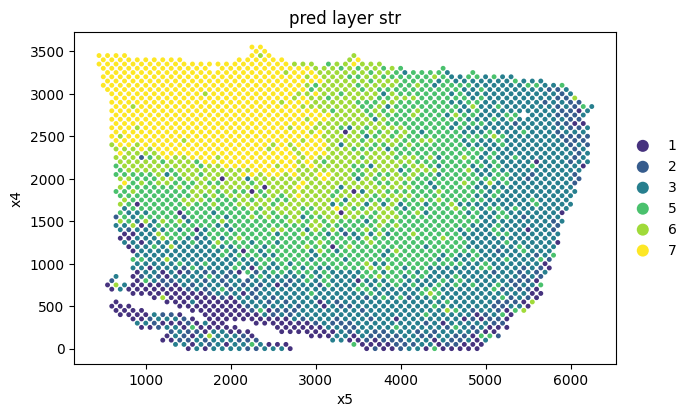

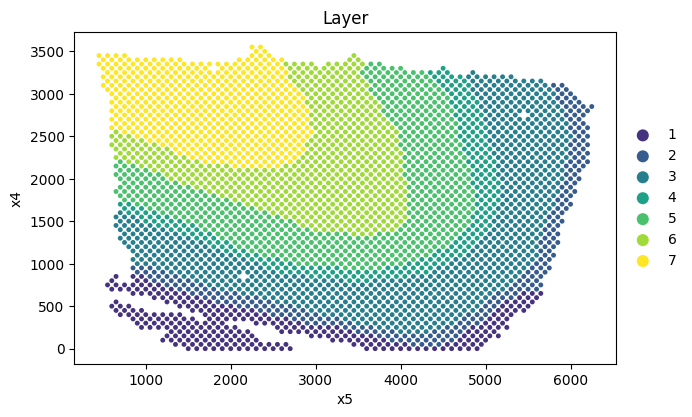

In [14]:
EvaluateOrg(testdata = dataSectionT4_SPARK200, 
            tissueID = 151676, 
            traindata = dataSectionM_SPARK200,
            class_num = 7,
            folder = "output/LIBD",
            name = "Pred_LIBD_SPARK200"
            )

In [15]:
OverallAccSummary("output\LIBD151676\Pred_LIBD_SPARK200_probmat.csv")

0.6639463713203148
0.9070241911979015


[np.float64(0.6639463713203148), np.float64(0.9070241911979015)]

In [53]:
sc.pp.highly_variable_genes(dataSectionM, n_top_genes=651)
dataSectionM[:,dataSectionM.var.index[dataSectionM.var['highly_variable']]]

View of AnnData object with n_obs × n_vars = 10904 × 651
    obs: 'x2', 'x3', 'Layer', 'Layer_character', 'n_counts', 'batch'
    var: 'gene_ids', 'feature_types', 'genome', 'genename', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'

In [ ]:
dataSectionT4_HVG651 = dataSectionT4_NoZero[:,dataSectionM.var.index[dataSectionM.var['highly_variable']]]

In [54]:
dataSectionM_HVG651 = dataSectionM[:,dataSectionM.var.index[dataSectionM.var['highly_variable']]]

In [55]:
LIBD_KANHVG651 = FitPredModelNE_KAN(dataSection1 = dataSectionM_HVG651,
                                                 filename3 = "output/LIBD/KAN5_Pred_LIBD_HVG651.obj",
                                                 hidden_dims = [500,250, 100, 50, 25],
                                  layer_weights = layer_weights)

100%|██████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:30<00:00, 90.13it/s]


Epoch:1, Loss:8892.8547


100%|██████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:30<00:00, 90.24it/s]


Epoch:2, Loss:21036.9462


100%|██████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:30<00:00, 90.09it/s]


...

Epoch:143, Loss:1274.6931


100%|██████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:35<00:00, 76.98it/s]


Epoch:144, Loss:1267.1452


100%|██████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:49<00:00, 55.46it/s]

Epoch:145, Loss:1289.3006
New learning rate:7.62939453125e-08


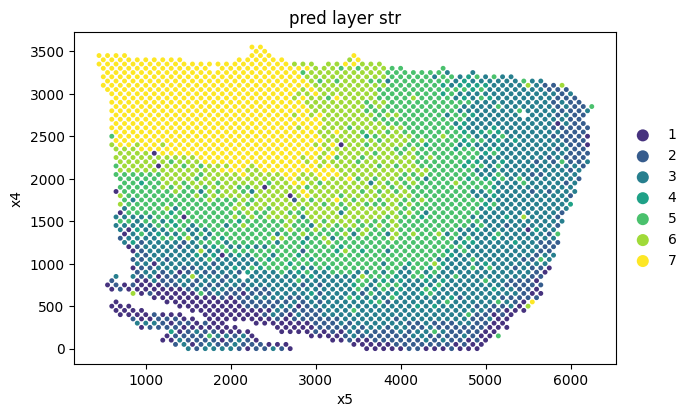

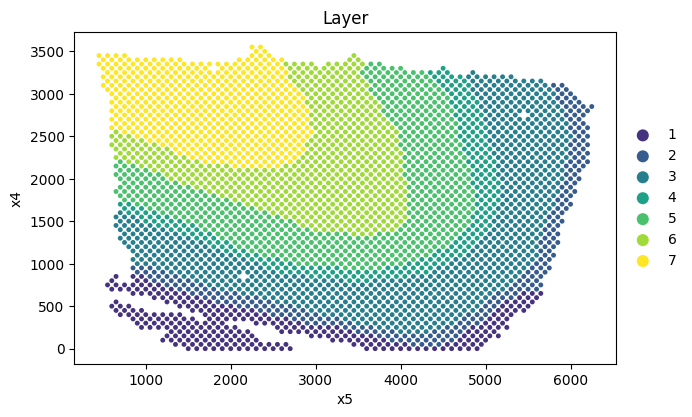

In [59]:
EvaluateOrg(testdata = dataSectionT4_HVG651, 
            tissueID = 151676, 
            traindata = dataSectionM,
            class_num = 7,
            folder = "output/LIBD",
            name = "KAN5_Pred_LIBD_HVG651"
            )

In [60]:
OverallAccSummary("output\LIBD151676\KAN5_Pred_LIBD_HVG651_probmat.csv")

0.7196152725153017
0.9556980472165549


[np.float64(0.7196152725153017), np.float64(0.9556980472165549)]

In [11]:
sc.pp.highly_variable_genes(dataSectionM, n_top_genes=349)
dataSectionM_HVG349 = dataSectionM[:,dataSectionM.var.index[dataSectionM.var['highly_variable']]]

In [12]:
dataSectionT4_HVG349 = dataSectionT4_NoZero[:,dataSectionM.var.index[dataSectionM.var['highly_variable']]]

In [68]:
LIBD_KANHVG651 = FitPredModelNE_KAN(dataSection1 = dataSectionM_HVG349,
                                                 filename3 = "output/LIBD/KAN5_Pred_LIBD_HVG349.obj",
                                                 hidden_dims = [500,250, 100, 50, 25],
                                  layer_weights = layer_weights)

100%|██████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:30<00:00, 90.18it/s]


Epoch:1, Loss:15909.2485


100%|██████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:29<00:00, 92.30it/s]


Epoch:2, Loss:20130.2575


100%|██████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:31<00:00, 85.54it/s]


...

Epoch:140, Loss:1587.7190


100%|██████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:29<00:00, 91.47it/s]


Epoch:141, Loss:1540.5182


100%|██████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:28<00:00, 94.09it/s]

Epoch:142, Loss:1613.9066
New learning rate:7.62939453125e-08


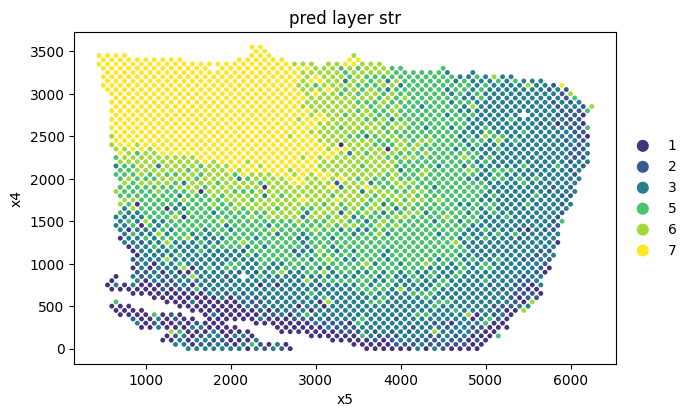

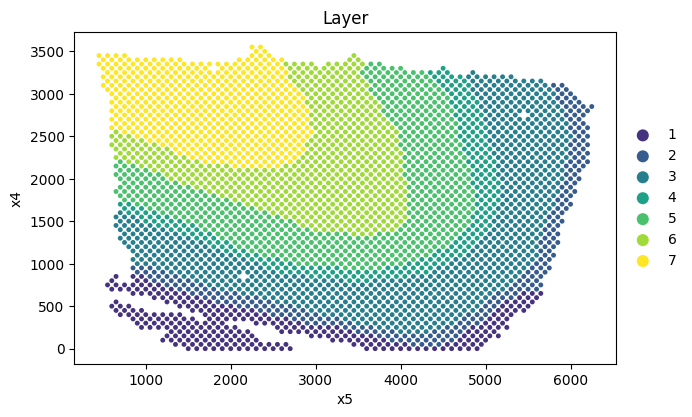

In [13]:
EvaluateOrg(testdata = dataSectionT4_HVG349, 
            tissueID = 151676, 
            traindata = dataSectionM,
            class_num = 7,
            folder = "output/LIBD",
            name = "KAN5_Pred_LIBD_HVG349"
            )

In [14]:
OverallAccSummary("output\LIBD151676\KAN5_Pred_LIBD_HVG349_probmat.csv")

0.6904692509472456
0.9128533955115126


[np.float64(0.6904692509472456), np.float64(0.9128533955115126)]

In [15]:
sc.pp.highly_variable_genes(dataSectionM, n_top_genes=166)
dataSectionM_HVG166 = dataSectionM[:,dataSectionM.var.index[dataSectionM.var['highly_variable']]]

In [16]:
dataSectionT4_HVG166 = dataSectionT4_NoZero[:,dataSectionM.var.index[dataSectionM.var['highly_variable']]]

In [17]:
LIBD_KANHVG651 = FitPredModelNE_KAN(dataSection1 = dataSectionM_HVG166,
                                                 filename3 = "output/LIBD/KAN5_Pred_LIBD_HVG166.obj",
                                                 hidden_dims = [500,250, 100, 50, 25],
                                  layer_weights = layer_weights)

100%|██████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:29<00:00, 93.66it/s]


Epoch:1, Loss:11287.0745


100%|██████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:28<00:00, 95.61it/s]


Epoch:2, Loss:10242.2762


100%|██████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:28<00:00, 95.74it/s]


...

Epoch:152, Loss:1600.3487


100%|██████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:28<00:00, 95.35it/s]


Epoch:153, Loss:1584.5351


100%|██████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:28<00:00, 95.10it/s]

Epoch:154, Loss:1618.1610
New learning rate:7.62939453125e-08


0.6289711454386476
0.8705916642378315


[np.float64(0.6289711454386476), np.float64(0.8705916642378315)]

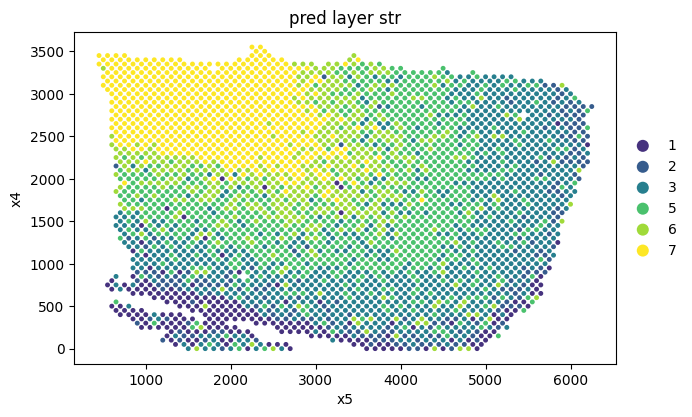

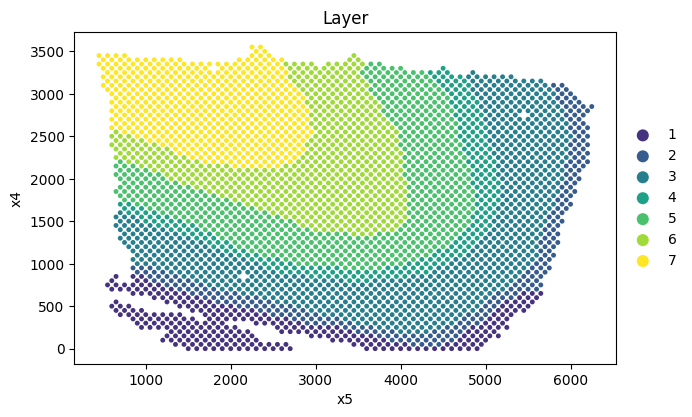

In [18]:
EvaluateOrg(testdata = dataSectionT4_HVG166, #
            tissueID = 151676, 
            traindata = dataSectionM,
            class_num = 7,
            folder = "output/LIBD",
            name = "KAN5_Pred_LIBD_HVG166"#
            )
OverallAccSummary("output\LIBD151676\KAN5_Pred_LIBD_HVG166_probmat.csv")#

In [40]:
sc.pp.highly_variable_genes(dataSectionM, n_top_genes=651)
dataSectionM[:,dataSectionM.var.index[dataSectionM.var['highly_variable']]]

View of AnnData object with n_obs × n_vars = 10904 × 651
    obs: 'x2', 'x3', 'Layer', 'Layer_character', 'n_counts', 'batch'
    var: 'gene_ids', 'feature_types', 'genome', 'genename', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'

In [20]:
dataSectionT4_HVG651 = dataSectionT4_NoZero[:,dataSectionM.var.index[dataSectionM.var['highly_variable']]]

In [21]:
dataSectionM_HVG651 = dataSectionM[:,dataSectionM.var.index[dataSectionM.var['highly_variable']]]

In [22]:
FitPredModelNE_DNN(dataSection1 = dataSectionM_HVG651,
                                                 filename3 = "output/LIBD/DNN3S_Pred_LIBD_HVG651.obj",
                                                 hidden_dims = [50, 25, 10],
                                  layer_weights = layer_weights)

100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 475.66it/s]


Epoch:1, Loss:7411.0602


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 468.55it/s]


Epoch:2, Loss:4739.9362


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 479.00it/s]


...

100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 480.69it/s]


Epoch:118, Loss:1822.8956


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 480.61it/s]

Epoch:119, Loss:1767.5947
New learning rate:7.62939453125e-08


DNN3_LIBD(
  (fclayer1): Sequential(
    (0): Linear(in_features=651, out_features=50, bias=True)
    (1): ReLU()
  )
  (fclayer2): Sequential(
    (0): Linear(in_features=50, out_features=25, bias=True)
    (1): ReLU()
  )
  (fclayer3): Sequential(
    (0): Linear(in_features=25, out_features=10, bias=True)
    (1): ReLU()
  )
  (fclayer4): Sequential(
    (0): Linear(in_features=10, out_features=1, bias=True)
  )
)

0.701544739143107
0.9303410084523462


[np.float64(0.701544739143107), np.float64(0.9303410084523462)]

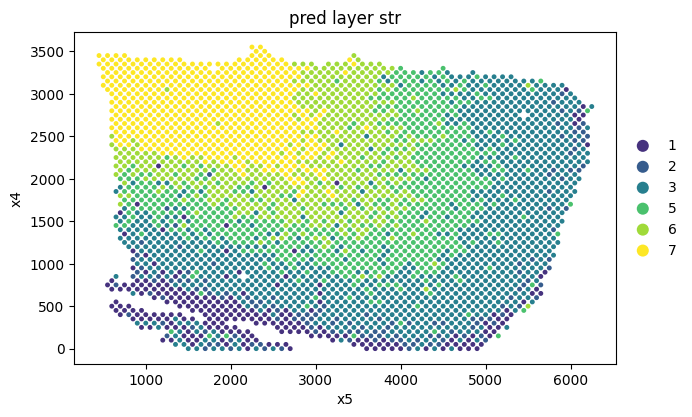

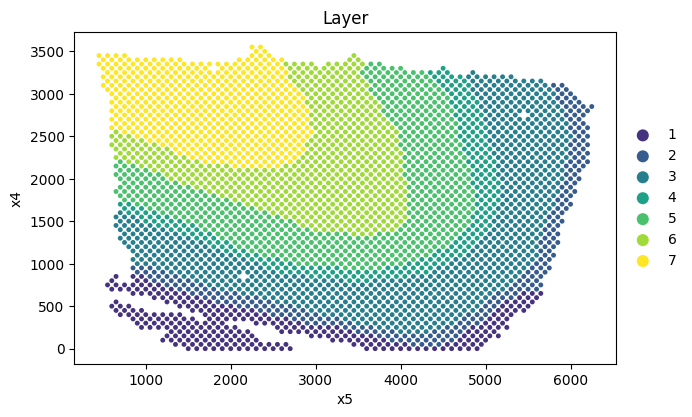

In [23]:
EvaluateOrg(testdata = dataSectionT4_HVG651, #
            tissueID = 151676, 
            traindata = dataSectionM,
            class_num = 7,
            folder = "output/LIBD",
            name = "DNN3S_Pred_LIBD_HVG651"#
            )
OverallAccSummary("output\LIBD151676\DNN3S_Pred_LIBD_HVG651_probmat.csv")#

In [24]:
sc.pp.highly_variable_genes(dataSectionM, n_top_genes=349)
dataSectionM_HVG349 = dataSectionM[:,dataSectionM.var.index[dataSectionM.var['highly_variable']]]

In [25]:
dataSectionT4_HVG349 = dataSectionT4_NoZero[:,dataSectionM.var.index[dataSectionM.var['highly_variable']]]

In [26]:
FitPredModelNE_DNN(dataSection1 = dataSectionM_HVG349,
                                                 filename3 = "output/LIBD/DNN3S_Pred_LIBD_HVG349.obj",
                                                 hidden_dims = [50, 25, 10],
                                  layer_weights = layer_weights)

100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 476.91it/s]


Epoch:1, Loss:7396.0104


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 468.79it/s]


Epoch:2, Loss:4944.1801


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 466.78it/s]


...

100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 492.95it/s]


Epoch:124, Loss:2239.8551


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 481.71it/s]

Epoch:125, Loss:2303.6064
New learning rate:7.62939453125e-08


DNN3_LIBD(
  (fclayer1): Sequential(
    (0): Linear(in_features=349, out_features=50, bias=True)
    (1): ReLU()
  )
  (fclayer2): Sequential(
    (0): Linear(in_features=50, out_features=25, bias=True)
    (1): ReLU()
  )
  (fclayer3): Sequential(
    (0): Linear(in_features=25, out_features=10, bias=True)
    (1): ReLU()
  )
  (fclayer4): Sequential(
    (0): Linear(in_features=10, out_features=1, bias=True)
  )
)

0.6589915476537452
0.8997376858058874


[np.float64(0.6589915476537452), np.float64(0.8997376858058874)]

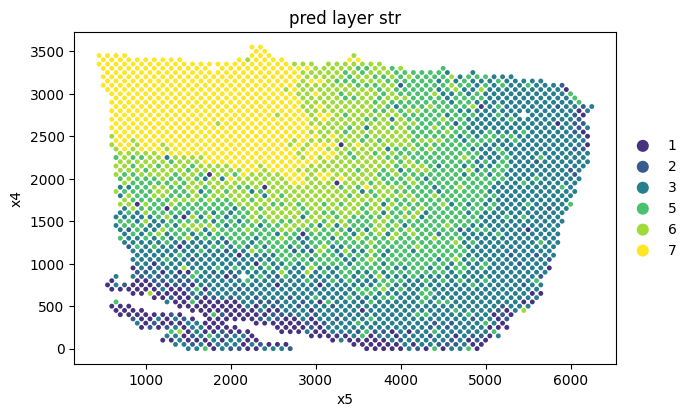

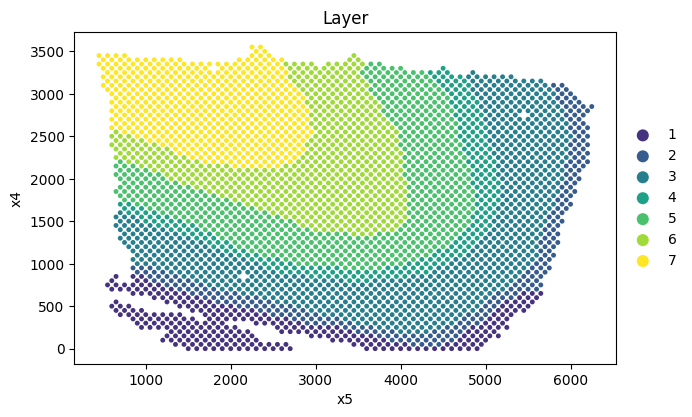

In [27]:
EvaluateOrg(testdata = dataSectionT4_HVG349, #
            tissueID = 151676, 
            traindata = dataSectionM,
            class_num = 7,
            folder = "output/LIBD",
            name = "DNN3S_Pred_LIBD_HVG349"#
            )
OverallAccSummary("output\LIBD151676\DNN3S_Pred_LIBD_HVG349_probmat.csv")#

In [41]:
sc.pp.highly_variable_genes(dataSectionM, n_top_genes=166)
dataSectionM_HVG166 = dataSectionM[:,dataSectionM.var.index[dataSectionM.var['highly_variable']]]

In [29]:
dataSectionT4_HVG166 = dataSectionT4_NoZero[:,dataSectionM.var.index[dataSectionM.var['highly_variable']]]

In [30]:
FitPredModelNE_DNN(dataSection1 = dataSectionM_HVG166,
                                                 filename3 = "output/LIBD/DNN3S_Pred_LIBD_HVG166.obj",
                                                 hidden_dims = [50, 25, 10],
                                  layer_weights = layer_weights)

100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 479.34it/s]


Epoch:1, Loss:7664.2177


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 484.88it/s]


Epoch:2, Loss:5343.6327


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 484.76it/s]


...

100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:06<00:00, 393.02it/s]


Epoch:111, Loss:3010.4365


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:06<00:00, 399.06it/s]

Epoch:112, Loss:3024.3536
New learning rate:7.62939453125e-08


DNN3_LIBD(
  (fclayer1): Sequential(
    (0): Linear(in_features=166, out_features=50, bias=True)
    (1): ReLU()
  )
  (fclayer2): Sequential(
    (0): Linear(in_features=50, out_features=25, bias=True)
    (1): ReLU()
  )
  (fclayer3): Sequential(
    (0): Linear(in_features=25, out_features=10, bias=True)
    (1): ReLU()
  )
  (fclayer4): Sequential(
    (0): Linear(in_features=10, out_features=1, bias=True)
  )
)

0.6088603905566891
0.8653453803555815


[np.float64(0.6088603905566891), np.float64(0.8653453803555815)]

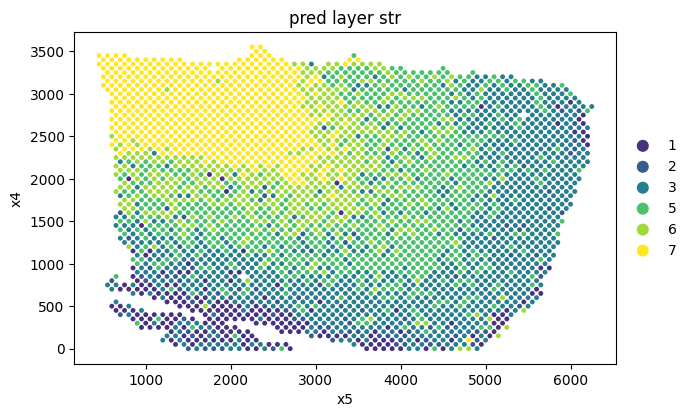

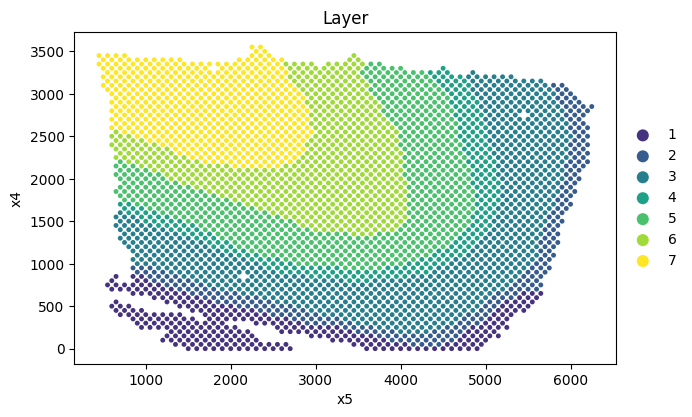

In [31]:
EvaluateOrg(testdata = dataSectionT4_HVG166, #
            tissueID = 151676, 
            traindata = dataSectionM,
            class_num = 7,
            folder = "output/LIBD",
            name = "DNN3S_Pred_LIBD_HVG166"#
            )
OverallAccSummary("output\LIBD151676\DNN3S_Pred_LIBD_HVG166_probmat.csv")#

In [42]:
# Loading SPARK genes:

import pandas as pd

# 读取 CSV 文件并指定第一列（基因名）作为索引
df = pd.read_csv("F:/WiK/R/top1000genes&Value.csv", index_col=0)

# 将基因名称提取为列表
gene_list = df.index.tolist()

# 查看基因名称列表
print(gene_list)

['MALAT1', 'COX6C', 'MGP', 'KRT19', 'HLA-A', 'MYL9', 'FTL', 'EEF1A1', 'SPARC', 'AQP4', 'RPL13A', 'TAGLN', 'RPS27', 'B2M', 'AGT', 'CXCL14', 'H2AFJ', 'NUPR1', 'KRT8', 'HLA-DRA', 'ENC1', 'AZGP1', 'HBA2', 'PTGDS', 'RPS19', 'TFF3', 'BAMBI', 'IFI27', 'CD74', 'KRT18', 'HLA-B', 'HPCAL1', 'SERPINE2', 'HOPX', 'OLFM1', 'PCDH8', 'TESPA1', 'CADM3', 'RBP4', 'NSG2', 'VSTM2A', 'MEF2C', 'TFF1', 'MIF', 'SLC12A5', 'CUX2', 'NEFL', 'GAP43', 'SNCG', 'NEFM', 'ATP1A1', 'GABRD', 'MDH1', 'INA', 'HAPLN4', 'CRYM', 'CABP1', 'CARTPT', 'CA10', 'ATP2B2', 'CALB1', 'SLC30A3', 'VSTM2L', 'NSF', 'CBLN4', 'SCN1B', 'NEFH', 'DCLK1', 'PVALB', 'ALDOA', 'PCP4', 'DIRAS2', 'MBP', 'KRT17', 'SCGB2A2', 'TF', 'SCGB1D2', 'MTURN', 'B3GALT2', 'MOBP', 'CRYAB', 'TUBA1A', 'S100B', 'CLDND1', 'SCD', 'CPB1', 'APLP1', 'SPP1', 'ERMN', 'SEPT4', 'RNASE1', 'BCAS1', 'SELENOP', 'MAG', 'QDPR', 'PAQR6', 'QKI', 'PPP1R14A', 'MAL', 'CARNS1', 'LINC00844', 'OPALIN', 'HBB', 'GPM6B', 'MUC1', 'CLDN11', 'SORT1', 'TP53INP2', 'NDRG1', 'IFITM3', 'TSC22D4', 'CSRP1

In [52]:
# 1425
FitPredModelNE_DNN(dataSection1 = dataSectionM,
                                                 filename3 = "output/LIBD/DNN3S_Pred_LIBD_1425.obj",
                                                 hidden_dims = [50, 25, 10],
                                  layer_weights = layer_weights)

100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:06<00:00, 433.32it/s]


Epoch:1, Loss:7521.7158


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:06<00:00, 449.53it/s]


Epoch:2, Loss:4749.8402


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:06<00:00, 443.17it/s]


...

100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:06<00:00, 447.39it/s]


Epoch:128, Loss:1573.3486


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:06<00:00, 446.66it/s]

Epoch:129, Loss:1524.6475
New learning rate:7.62939453125e-08


DNN3_LIBD(
  (fclayer1): Sequential(
    (0): Linear(in_features=1425, out_features=50, bias=True)
    (1): ReLU()
  )
  (fclayer2): Sequential(
    (0): Linear(in_features=50, out_features=25, bias=True)
    (1): ReLU()
  )
  (fclayer3): Sequential(
    (0): Linear(in_features=25, out_features=10, bias=True)
    (1): ReLU()
  )
  (fclayer4): Sequential(
    (0): Linear(in_features=10, out_features=1, bias=True)
  )
)

0.6925094724570097
0.9370445934129992


[np.float64(0.6925094724570097), np.float64(0.9370445934129992)]

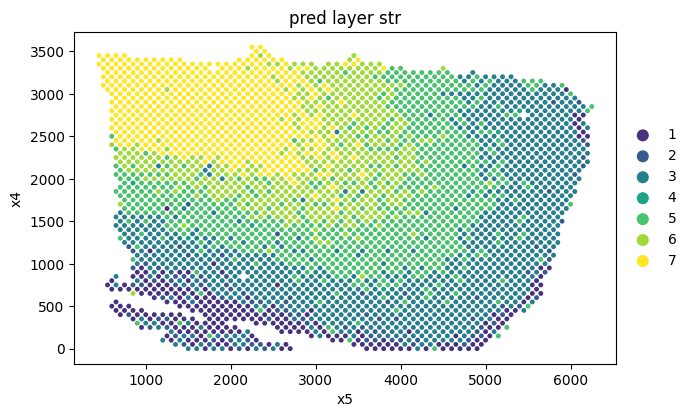

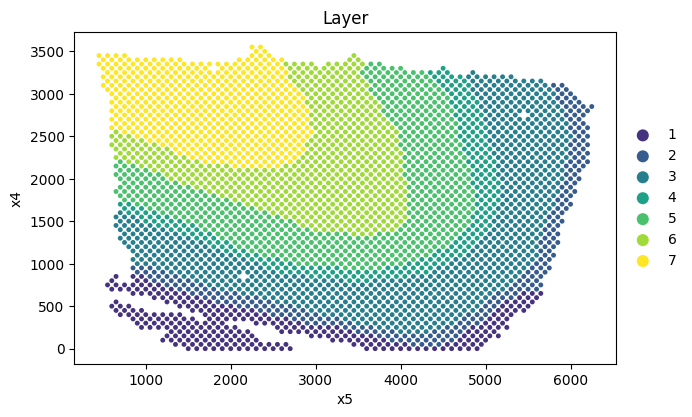

In [53]:
EvaluateOrg(testdata = dataSectionT4_NoZero, #
            tissueID = 151676, 
            traindata = dataSectionM,
            class_num = 7,
            folder = "output/LIBD",
            name = "DNN3S_Pred_LIBD_1425"#
            )
OverallAccSummary("output\LIBD151676\DNN3S_Pred_LIBD_1425_probmat.csv")#

In [37]:
dataSectionM_SPARK651 = dataSectionM[:,gene_list[0:651]]

In [38]:
FitPredModelNE_DNN(dataSection1 = dataSectionM_SPARK651,
                                                 filename3 = "output/LIBD/DNN3S_Pred_LIBD_SPARK651.obj",
                                                 hidden_dims = [50, 25, 10],
                                  layer_weights = layer_weights)

100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:06<00:00, 445.02it/s]


Epoch:1, Loss:7618.1130


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:06<00:00, 453.69it/s]


Epoch:2, Loss:4798.8472


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:06<00:00, 436.26it/s]


...

100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:06<00:00, 451.67it/s]


Epoch:123, Loss:1919.2932


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 464.53it/s]

Epoch:124, Loss:1802.2789
New learning rate:7.62939453125e-08


DNN3_LIBD(
  (fclayer1): Sequential(
    (0): Linear(in_features=651, out_features=50, bias=True)
    (1): ReLU()
  )
  (fclayer2): Sequential(
    (0): Linear(in_features=50, out_features=25, bias=True)
    (1): ReLU()
  )
  (fclayer3): Sequential(
    (0): Linear(in_features=25, out_features=10, bias=True)
    (1): ReLU()
  )
  (fclayer4): Sequential(
    (0): Linear(in_features=10, out_features=1, bias=True)
  )
)

0.7038764208685514
0.9347129116875545


[np.float64(0.7038764208685514), np.float64(0.9347129116875545)]

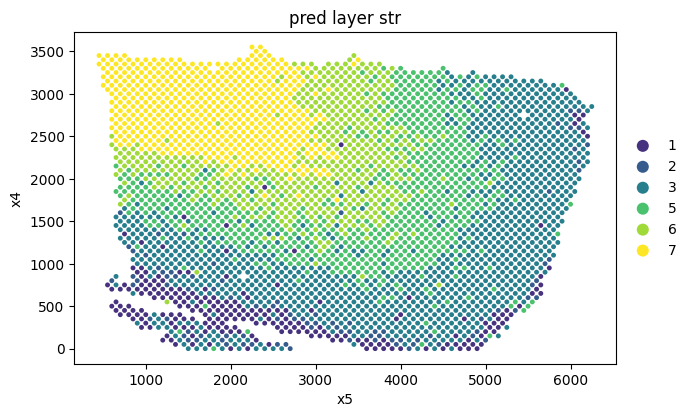

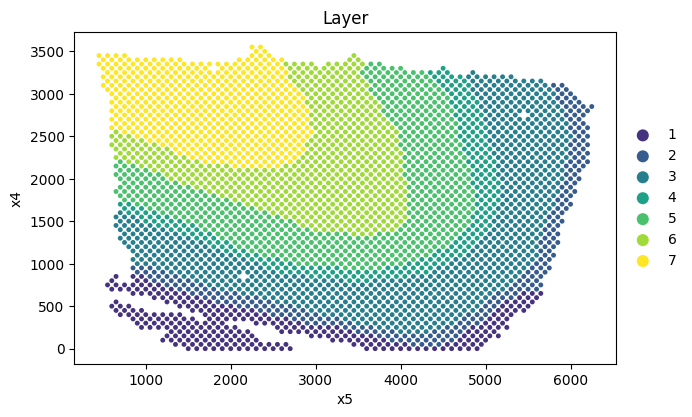

In [49]:
EvaluateOrg(testdata = dataSectionT4_NoZero[:,gene_list[0:651]], #
            tissueID = 151676, 
            traindata = dataSectionM,
            class_num = 7,
            folder = "output/LIBD",
            name = "DNN3S_Pred_LIBD_SPARK651"#
            )
OverallAccSummary("output\LIBD151676\DNN3S_Pred_LIBD_SPARK651_probmat.csv")#

In [40]:
dataSectionM_SPARK349 = dataSectionM[:,gene_list[0:349]]

In [41]:
FitPredModelNE_DNN(dataSection1 = dataSectionM_SPARK349,
                                                 filename3 = "output/LIBD/DNN3S_Pred_LIBD_SPARK349.obj",
                                                 hidden_dims = [50, 25, 10],
                                  layer_weights = layer_weights)

100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:06<00:00, 446.46it/s]


Epoch:1, Loss:7319.0955


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 459.63it/s]


Epoch:2, Loss:4773.0192


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 464.25it/s]


...

100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 470.14it/s]


Epoch:121, Loss:2068.7441


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 464.85it/s]

Epoch:122, Loss:2089.0886
New learning rate:7.62939453125e-08


DNN3_LIBD(
  (fclayer1): Sequential(
    (0): Linear(in_features=349, out_features=50, bias=True)
    (1): ReLU()
  )
  (fclayer2): Sequential(
    (0): Linear(in_features=50, out_features=25, bias=True)
    (1): ReLU()
  )
  (fclayer3): Sequential(
    (0): Linear(in_features=25, out_features=10, bias=True)
    (1): ReLU()
  )
  (fclayer4): Sequential(
    (0): Linear(in_features=10, out_features=1, bias=True)
  )
)

0.6960069950451764
0.9317983095307492


[np.float64(0.6960069950451764), np.float64(0.9317983095307492)]

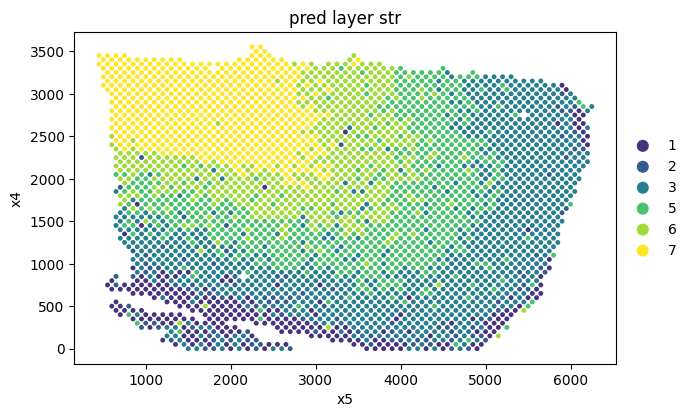

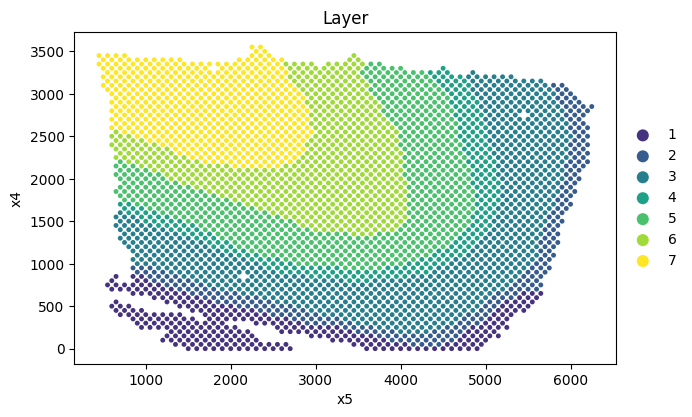

In [50]:
EvaluateOrg(testdata = dataSectionT4_NoZero[:,gene_list[0:349]], #
            tissueID = 151676, 
            traindata = dataSectionM,
            class_num = 7,
            folder = "output/LIBD",
            name = "DNN3S_Pred_LIBD_SPARK349"#
            )
OverallAccSummary("output\LIBD151676\DNN3S_Pred_LIBD_SPARK349_probmat.csv")#

In [43]:
dataSectionM_SPARK166 = dataSectionM[:,gene_list[0:166]]

In [44]:
FitPredModelNE_DNN(dataSection1 = dataSectionM_SPARK166,
                                                 filename3 = "output/LIBD/DNN3S_Pred_LIBD_SPARK166.obj",
                                                 hidden_dims = [50, 25, 10],
                                  layer_weights = layer_weights)

100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 472.99it/s]


Epoch:1, Loss:7475.6786


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 473.08it/s]


Epoch:2, Loss:4984.3167


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 477.38it/s]


...

100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 462.17it/s]


Epoch:119, Loss:2465.2869


100%|█████████████████████████████████████████████████████████████████████████████| 2726/2726 [00:05<00:00, 463.50it/s]

Epoch:120, Loss:2439.3749
New learning rate:7.62939453125e-08


DNN3_LIBD(
  (fclayer1): Sequential(
    (0): Linear(in_features=166, out_features=50, bias=True)
    (1): ReLU()
  )
  (fclayer2): Sequential(
    (0): Linear(in_features=50, out_features=25, bias=True)
    (1): ReLU()
  )
  (fclayer3): Sequential(
    (0): Linear(in_features=25, out_features=10, bias=True)
    (1): ReLU()
  )
  (fclayer4): Sequential(
    (0): Linear(in_features=10, out_features=1, bias=True)
  )
)

0.6595744680851063
0.9064412707665404


[np.float64(0.6595744680851063), np.float64(0.9064412707665404)]

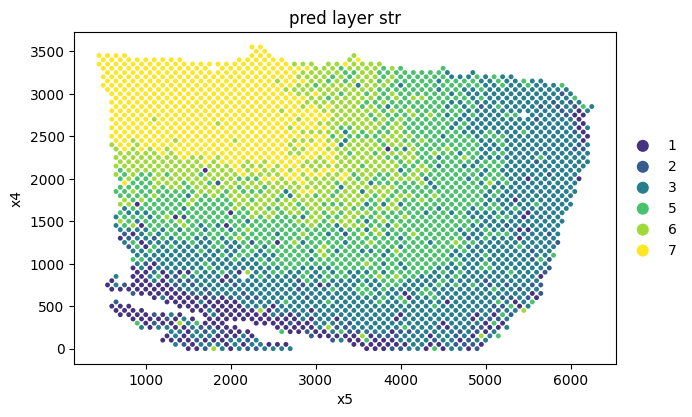

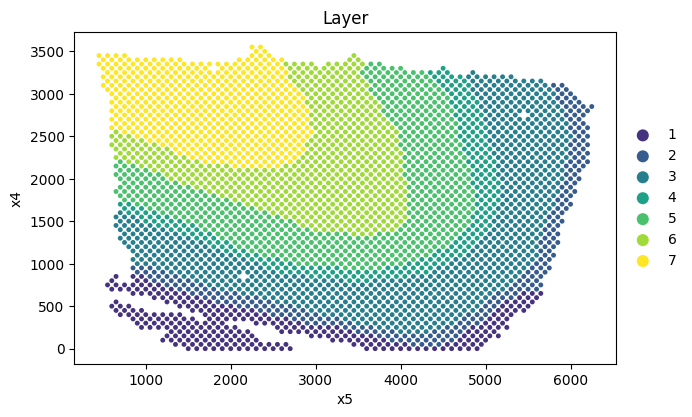

In [51]:
EvaluateOrg(testdata = dataSectionT4_NoZero[:,gene_list[0:166]], #
            tissueID = 151676, 
            traindata = dataSectionM,
            class_num = 7,
            folder = "output/LIBD",
            name = "DNN3S_Pred_LIBD_SPARK166"#
            )
OverallAccSummary("output\LIBD151676\DNN3S_Pred_LIBD_SPARK166_probmat.csv")#

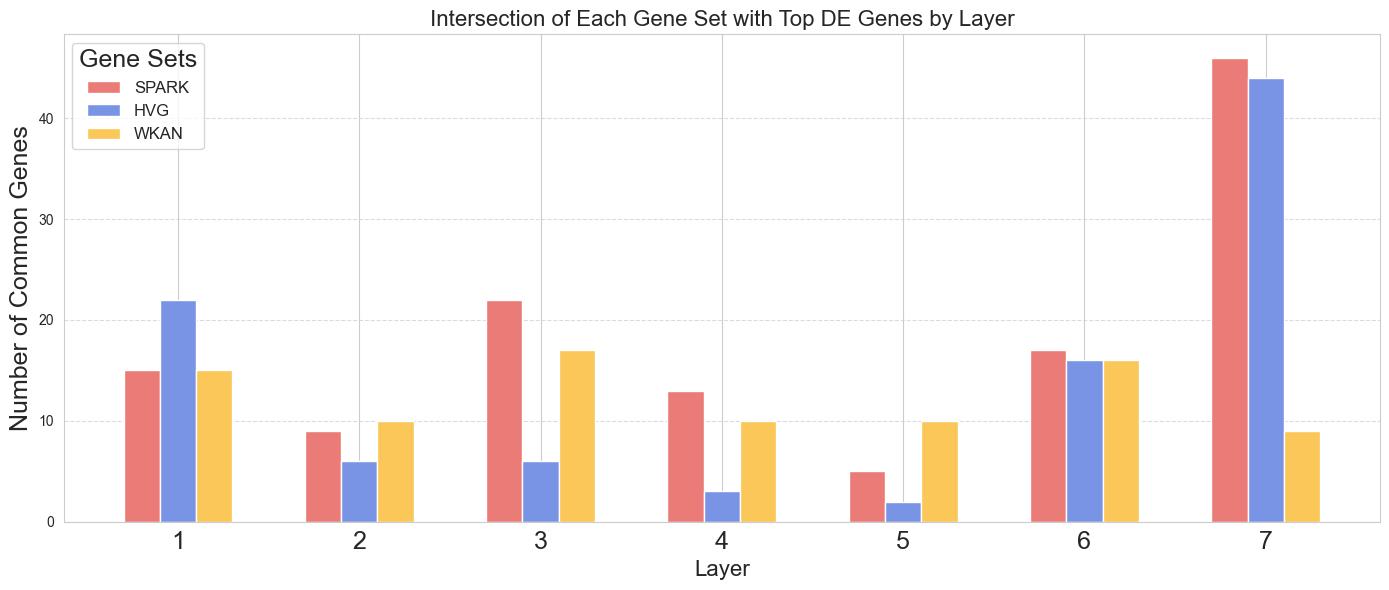

   Layer  SPARK  HVG  WKAN
0      1     15   22    15
1      2      9    6    10
2      3     22    6    17
3      4     13    3    10
4      5      5    2    10
5      6     17   16    16
6      7     46   44     9


In [109]:
# Step 1: 计算每个集合与 top_DE 每层的交集
intersection_results = {}
for gene_set_name, gene_set in gene_sets.items():
    intersections = {layer: len(gene_set & genes) for layer, genes in top_DE.items()}
    intersection_results[gene_set_name] = intersections

# top_DE 每层的基因集
top_DE = {
    1: set(top_DE[1]),
    2: set(top_DE[2]),
    3: set(top_DE[3]),
    4: set(top_DE[4]),
    5: set(top_DE[5]),
    6: set(top_DE[6]),
    7: set(top_DE[7])
}

# 定义三个集合
gene_sets = {
    "SPARK": set(SPARK_gene_list166),
    "HVG": set(HVG_gene_list166),
    "WKAN": set(WK_gene_list166)
}

# Step 1: 计算每个集合与 top_DE 每层的交集
intersection_results = {}
for gene_set_name, gene_set in gene_sets.items():
    intersections = {layer: len(gene_set & genes) for layer, genes in top_DE.items()}
    intersection_results[gene_set_name] = intersections
# 转换为 DataFrame
intersection_df = pd.DataFrame(intersection_results)
intersection_df.index.name = "Layer"
intersection_df.reset_index(inplace=True)

# Step 2: 设置自定义颜色
custom_colors = ["#ea7b77", "#7a94e5", "#FAC758"]  # 自定义颜色列表

# Step 3: 设置 seaborn 样式
sns.set_style("whitegrid")

# Step 4: 绘制柱状图
fig, ax = plt.subplots(figsize=(14, 6))
width = 0.2  # 每组柱的宽度
x = intersection_df["Layer"]

# 绘制每组柱状图
for i, column in enumerate(intersection_df.columns[1:]):
    ax.bar(
        x + i * width, 
        intersection_df[column], 
        width=width, 
        label=column, 
        color=custom_colors[i],
  
    )

# 美化图像
ax.set_title("Intersection of Each Gene Set with Top DE Genes by Layer", fontsize=16)
ax.set_xlabel("Layer", fontsize=16)
ax.set_ylabel("Number of Common Genes", fontsize=18)
ax.set_xticks(x + width)  # 调整 x 轴刻度
ax.set_xticklabels(intersection_df["Layer"], fontsize=18)
ax.legend(title="Gene Sets", fontsize=12, title_fontsize=18)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# 调整布局并保存
plt.tight_layout()
plt.savefig("Gene_Set_vs_Layers.png", dpi=1600)
plt.show()

# 打印结果
print(intersection_df)

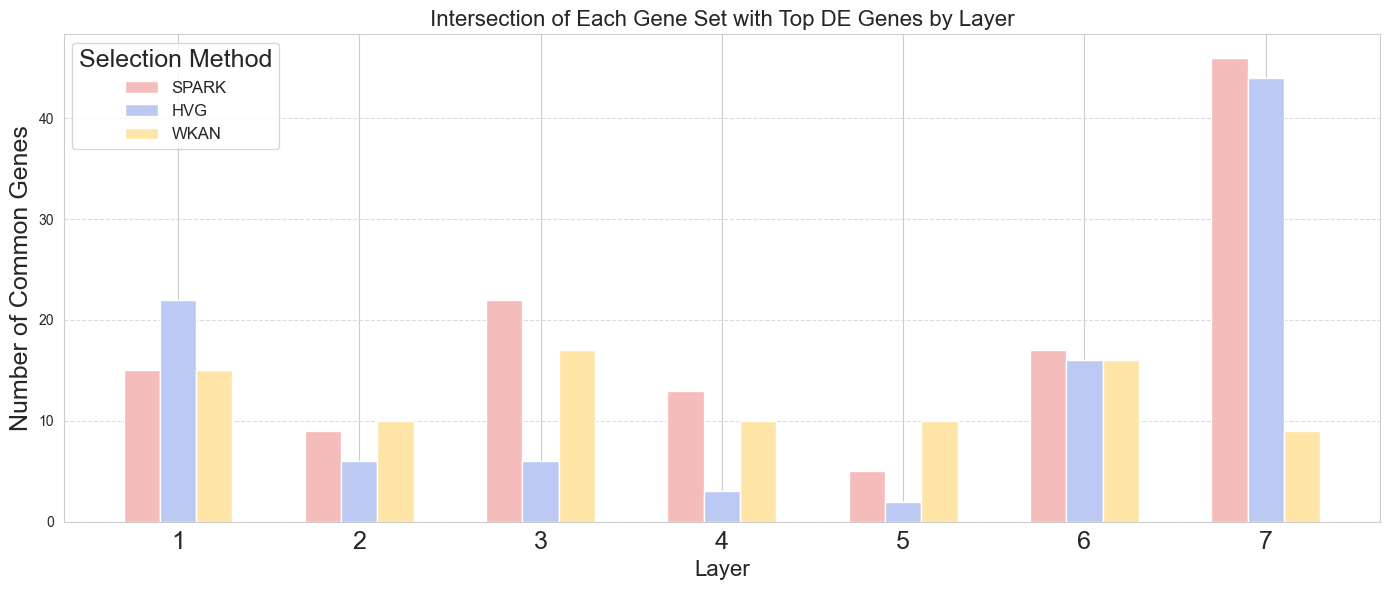

   Layer  SPARK  HVG  WKAN
0      1     15   22    15
1      2      9    6    10
2      3     22    6    17
3      4     13    3    10
4      5      5    2    10
5      6     17   16    16
6      7     46   44     9


In [51]:
# Step 1: 计算每个集合与 top_DE 每层的交集
intersection_results = {}
for gene_set_name, gene_set in gene_sets.items():
    intersections = {layer: len(gene_set & genes) for layer, genes in top_DE.items()}
    intersection_results[gene_set_name] = intersections

# top_DE 每层的基因集
top_DE = {
    1: set(top_DE[1]),
    2: set(top_DE[2]),
    3: set(top_DE[3]),
    4: set(top_DE[4]),
    5: set(top_DE[5]),
    6: set(top_DE[6]),
    7: set(top_DE[7])
}

# 定义三个集合
gene_sets = {
    "SPARK": set(SPARK_gene_list166),
    "HVG": set(HVG_gene_list166),
    "WKAN": set(WK_gene_list166)
}

# Step 1: 计算每个集合与 top_DE 每层的交集
intersection_results = {}
for gene_set_name, gene_set in gene_sets.items():
    intersections = {layer: len(gene_set & genes) for layer, genes in top_DE.items()}
    intersection_results[gene_set_name] = intersections
# 转换为 DataFrame
intersection_df = pd.DataFrame(intersection_results)
intersection_df.index.name = "Layer"
intersection_df.reset_index(inplace=True)

# Step 2: 设置自定义颜色
custom_colors = ["#F4BDBB", "#BCC9F2", "#FFE4A8"]  # 自定义颜色列表

# Step 3: 设置 seaborn 样式
sns.set_style("whitegrid")

# Step 4: 绘制柱状图
fig, ax = plt.subplots(figsize=(14, 6))
width = 0.2  # 每组柱的宽度
x = intersection_df["Layer"]

# 绘制每组柱状图
for i, column in enumerate(intersection_df.columns[1:]):
    ax.bar(
        x + i * width, 
        intersection_df[column], 
        width=width, 
        label=column, 
        color=custom_colors[i],
  
    )

# 美化图像
ax.set_title("Intersection of Each Gene Set with Top DE Genes by Layer", fontsize=16)
ax.set_xlabel("Layer", fontsize=16)
ax.set_ylabel("Number of Common Genes", fontsize=18)
ax.set_xticks(x + width)  # 调整 x 轴刻度
ax.set_xticklabels(intersection_df["Layer"], fontsize=18)
ax.legend(title="Selection Method", fontsize=12, title_fontsize=18)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# 调整布局并保存
plt.tight_layout()
plt.savefig("Gene_Set_vs_Layers.png", dpi=800)
plt.show()

# 打印结果
print(intersection_df)

# to tuto

In [7]:
top_DE = pd.read_csv('top_DE_genes_114514.csv',  header=None)

In [16]:
top_DE

,0,1,2,3,4,5,6,7
0,0,1,2,3,4,5,6,7
1,MALAT1,MALAT1,HPCAL1,ENC1,NEFL,PCP4,MBP,MBP
2,TFF1,CST3,CAMK2N1,HOPX,NEFM,TMSB10,SCGB2A2,PLP1
3,SCGB2A2,CLU,ENC1,YWHAH,NEFH,SNAP25,PLP1,CNP
4,MUC1,COX6C,SERPINE2,CCK,SCN1B,TUBB2A,DIRAS2,GFAP
5,SCGB1D2,GFAP,HOPX,NRGN,TUBA1B,SYT1,SCGB1D2,CRYAB
6,MGP,MT3,CXCL14,OLFM1,SNCG,TUBA1B,KRT17,MOBP
7,TFF3,MGP,PPP3CA,NDUFA4,VAMP1,STMN2,SLC17A7,TF
8,CLEC3A,MTRNR2L12,MALAT1,NEFL,UCHL1,SYN2,SYT1,S100B
9,NUPR1,KRT19,NCDN,GAP43,NDUFA4,NEFL,GPM6A,PTGDS


In [8]:
# Self-select from Self:
with open("output/LIBD/Pred_LIBD_FullG1425.obj",'rb') as file:
        LIBD_FullG = pickle.load(file)

In [11]:
WK_gene_list166 = dataSectionM[:, gene_filter(model_weight = LIBD_FullG.fclayer1[0].spline_scaler, top_n= 2)].var_names


In [12]:
WK_gene_list166

Index(['MALAT1', 'COX6C', 'CLU', 'CST3', 'CHCHD2', 'MT3', 'TUBA1B', 'GFAP',
       'MTRNR2L12', 'SNAP25',
       ...
       'CA2', 'WSB2', 'YWHAG', 'GAPDH', 'RAB6B', 'MAN1A2', 'BASP1', 'COL5A2',
       'FAM19A5', 'MUC5B'],
      dtype='object', length=166)

In [17]:
import pandas as pd

wk_set = set(WK_gene_list166)

top_DE_sets = {layer: set(top_DE[layer]) for layer in range(1, 8)}

intersection_genes = {layer: list(wk_set & top_DE_sets[layer]) for layer in range(1, 8)}

for layer in range(1, 8):
    print(f"Layer {layer}: {intersection_genes[layer]}")

Layer 1: ['COX6C', 'CLU', 'MALAT1', 'ACTA2', 'MTRNR2L12', 'EEF1A1', 'MT3', 'RPL13', 'CST3', 'PCSK1N', 'SPARCL1', 'GFAP', 'RPL41', 'CKB', 'RPLP1']
Layer 2: ['MALAT1', 'ATP2B1', 'PHYHIP', 'HPCAL1', 'CCK', 'CALM1', 'HOPX', 'ENC1', 'OLFM1', 'C1QL2']
Layer 3: ['NRGN', 'MTRNR2L12', 'CALM3', 'UCHL1', 'GAP43', 'OLFM1', 'CCK', 'CALM1', 'NDUFA4', 'CALB1', 'PCSK1N', 'HOPX', 'ENC1', 'VSNL1', 'CKB', 'INA', 'RTN1']
Layer 4: ['NRGN', 'UCHL1', 'GAP43', 'TUBA1B', 'RORB', 'NDUFA4', 'GAPDH', 'SNAP25', 'MAP1B', 'INA']
Layer 5: ['YWHAG', 'BASP1', 'UCHL1', 'TUBA1B', 'TMSB10', 'TUBB2A', 'PCP4', 'SNAP25', 'MAP1B', 'RTN1']
Layer 6: ['SCN3B', 'TFF3', 'ATP2B1', 'COX6C', 'MBP', 'TMSB10', 'CCK', 'MUC1', 'RPS12', 'TUBB2A', 'GFAP', 'PRKCB', 'SCGB2A2', 'SNAP25', 'DYNLL1', 'THY1']
Layer 7: ['GPM6B', 'MBP', 'SPP1', 'MOBP', 'LINC00844', 'LHPP', 'PPP1R14A', 'FTH1', 'GFAP']


In [18]:
import pandas as pd

# Assuming top_DE is a DataFrame and WK_gene_list166 is a pandas Index object
# Merge all elements from top_DE (columns 1 to 7) into a single list and remove duplicates
top_DE_merged = pd.unique(top_DE.iloc[:, 1:8].values.ravel()).tolist()

# Convert WK_gene_list166 and merged top_DE list to sets
wk_set = set(WK_gene_list166)
top_DE_set = set(top_DE_merged)

# Compute the difference set (elements in WK_gene_list166 but not in top_DE)
difference_set = wk_set - top_DE_set

# Convert the difference set to a list and print
difference_list = list(difference_set)
print("Difference set (WK_gene_list166 - top_DE):", difference_list)

Difference set (WK_gene_list166 - top_DE): ['MAPK10', 'COX8A', 'SEC14L1', 'GPR162', 'UGT8', 'SYT4', 'SERPINI1', 'ZNF703', 'RPL37', 'RPS2', 'COL8A1', 'TUBB4B', 'STAC2', 'NR2F2', 'GRIK3', 'AGT', 'SSBP4', 'GATA3-AS1', 'SLC39A6', 'SHANK3', 'PREX1', 'COX6B1', 'PPP2R1A', 'MAN1A2', 'CDC14A', 'TMCO6', 'ATP5MC3', 'RPL32', 'RNF130', 'OXCT1', 'ARHGDIG', 'GRIA4', 'NUPR1', 'CSGALNACT1', 'DSP', 'UQCRB', 'IGLC2', 'LMOD1', 'ITPR3', 'AKAP5', 'MIF', 'CCL19', 'AL359091.1', 'OXR1', 'FAM19A2', 'SLC12A5', 'SNX10', 'HS6ST1', 'HLA-E', 'ZFP36L1', 'NSF', 'MUC5B', 'CYBA', 'C2CD4C', 'CREB3L4', 'PAM', 'GRIN2A', 'COX5B', 'HS3ST4', 'SCGB2A1', 'THEMIS', 'C9ORF16', 'CA2', 'SUB1', 'GLDN', 'MAN1A1', 'FBLL1', 'CDH24', 'S100A4', 'UQCRFS1', 'ID3', 'CYFIP2', 'ZNF10', 'DLGAP3', 'GNAS', 'RPL37A', 'LTBP4', 'RPS15', 'CCDC170', 'MB', 'WSB2', 'FAM19A5', 'TXNL4A', 'RPS4X', 'CADPS', 'LDB2', 'TMSB4X', 'AC245060.5', 'RPS15A', 'SYP', 'IGHA1', 'OLIG2', 'CHCHD2', 'PADI2', 'HSP90AA1', 'OGN', 'ATP5F1C', 'RAB6B', 'FGF13', 'C2ORF80', 'RXFP1

In [19]:
len(difference_list)

107